In [2]:
import numpy as np
import pandas as pd
import os, sys, glob
%load_ext autoreload
%autoreload 2
import RM_utils as utils
import nibabel as nib
from config import *
from nibabel import Nifti1Image
from scipy import stats
from nilearn.maskers import NiftiMasker, NiftiLabelsMasker
import matplotlib.pyplot as plt
import scprep, tphate, phate
from nilearn import plotting
import shutil
import seaborn as sns
from brainiak.searchlight.searchlight import Searchlight
from camcan_utils import get_brain_cmap
import skdim
import camcan_utils
import narratives_utils
import statsmodels.api as sm
import ide_helpers as ide


/gpfs/milgram/project/casey/elb77/conda_envs/env_tda/lib/python3.7/site-packages/nilearn/__init__.py:69: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [185]:
mask = utils.get_intersect_mask()
coords = np.where(mask.get_fdata() == 1)
for t in RM_DATA_DIRS.keys():
    for tp in ['PHATE_SE_at_t','TPHATE_SE_at_t','TPHATE_FisherS','PHATE_FisherS','DIFF_MAP_FisherS']:
        fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/IDE/LOSO/*{t.lower().capitalize()}*_{tp}*.nii.gz'))
        print(f'found {len(fns)} for {t} {tp}')
        data_all = np.zeros((len(fns), len(coords[0])))
        temp = np.zeros(mask.shape)
        for i, f in enumerate(fns):
            d = nib.load(f).get_fdata()
            data_all[i] = d[coords]
            temp = np.add(temp, d)
        temp /= len(fns)
        n = Nifti1Image(temp, affine=mask.affine)
        nib.save(n, f'{RM_RESULTS_DIR}/aggregated_nii/group_average_{t.upper()}_ide_{tp}_whole_brain_SL_rad5.nii.gz')
        np.save(f'{RM_RESULTS_DIR}/aggregated_npy/{t.upper()}_{tp}_all_subjects_results.npy', data_all)
        plot_fn = f'RestMovie/plots/group_average_{t.upper()}_ide_{tp}_whole_brain_SL_rad5.png'
        plotting.plot_img_on_surf(n, 
                                  views=['lateral','medial'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=plot_fn,
                                  darkness=0.8, 
                                  threshold=0, title=f'{t} {tp}',
                                 )
        plt.close()
        print(plot_fn)

found 11 for REST PHATE_SE_at_t
RestMovie/plots/group_average_REST_ide_PHATE_SE_at_t_whole_brain_SL_rad5.png
found 11 for REST TPHATE_SE_at_t
RestMovie/plots/group_average_REST_ide_TPHATE_SE_at_t_whole_brain_SL_rad5.png
found 11 for REST TPHATE_FisherS
RestMovie/plots/group_average_REST_ide_TPHATE_FisherS_whole_brain_SL_rad5.png
found 11 for REST PHATE_FisherS
RestMovie/plots/group_average_REST_ide_PHATE_FisherS_whole_brain_SL_rad5.png
found 11 for REST DIFF_MAP_FisherS
RestMovie/plots/group_average_REST_ide_DIFF_MAP_FisherS_whole_brain_SL_rad5.png
found 11 for AERONAUT PHATE_SE_at_t
RestMovie/plots/group_average_AERONAUT_ide_PHATE_SE_at_t_whole_brain_SL_rad5.png
found 11 for AERONAUT TPHATE_SE_at_t
RestMovie/plots/group_average_AERONAUT_ide_TPHATE_SE_at_t_whole_brain_SL_rad5.png
found 11 for AERONAUT TPHATE_FisherS
RestMovie/plots/group_average_AERONAUT_ide_TPHATE_FisherS_whole_brain_SL_rad5.png
found 11 for AERONAUT PHATE_FisherS
RestMovie/plots/group_average_AERONAUT_ide_PHATE_Fishe

In [56]:
# plot DMSE for different parameters

PARAMS = {'DIFF_MAP_SE': [(4,2),(5,2),(10,2),(20,2),(50,2)], 'TPHATE_SE': [(10,2), (20,10), (20,2), (20,5), (4,20), (50,10), (50,20), (50,2), (5,2)]}
mask = utils.get_intersect_mask()
coords = np.where(mask.get_fdata() == 1)
for t in RM_DATA_DIRS.keys():
    for tp in ['','DIFF_MAP_SE']:
        these_params = PARAMS[tp]
        for p in these_params:
            fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/IDE/LOSO/*{t.lower().capitalize()}*{tp}*{p[0]}_t{p[1]}_*.nii.gz'))
            data_list = np.zeros((len(fns), len(coords[0])))
            print(f'found {len(fns)} for {t},{tp},{p}')
            temp = np.zeros(mask.shape)
    
            for i, f in enumerate(fns):
                d = nib.load(f).get_fdata()
                data_list[i] = d[coords]                 
                temp = np.add(temp, d)
            temp /= len(fns)
            n = Nifti1Image(temp, affine=mask.affine)
            outfn = f'{RM_RESULTS_DIR}/aggregated_nii/group_average_{t.lower().capitalize()}_{tp}_knn{p[0]}_t{p[1]}_whole_brain_SL_rad5.nii.gz'
            nib.save(n, outfn+'.nii.gz')
            # n = nib.load(outfn)
            #save data 
            outnpy = f'{RM_RESULTS_DIR}/aggregated_npy/{t.upper()}_{tp}_knn{p[0]}_t{p[1]}_all_subjects_results.npy'
            np.save(outnpy, data_list)
            print('saved ',outnpy)
            plot_fn = f'RestMovie/plots/group_average_{t.lower().capitalize()}_{tp}_knn{p[0]}_t{p[1]}_whole_brain_SL_rad5.png'
            plotting.plot_img_on_surf(n, 
                                      views=['lateral','medial'], 
                                      cmap=cmap, 
                                      inflate=True, 
                                      bg_on_data=False, 
                                              alpha=0.8,
                                      output_file=plot_fn,
                                      darkness=0.8, 
                                      threshold=1, vmax=5, 
                                      title=f'{t} {tp} {p}',
                                     )
            plt.close()
            d=n.get_fdata()[coords]
            print(np.max(d), np.min(d), np.mean(d), np.std(d))
            print(plot_fn)

found 5 for REST,TPHATE_SE,(10, 2)
saved  /gpfs/milgram/project/turk-browne/users/elb77//task_dim/RestMovie/results/aggregated_npy/REST_TPHATE_SE_knn10_t2_all_subjects_results.npy
4.5208232313430186 0.0 3.9415751567596087 0.2765547326617341
RestMovie/plots/group_average_Rest_TPHATE_SE_knn10_t2_whole_brain_SL_rad5.png
found 5 for REST,TPHATE_SE,(20, 10)
saved  /gpfs/milgram/project/turk-browne/users/elb77//task_dim/RestMovie/results/aggregated_npy/REST_TPHATE_SE_knn20_t10_all_subjects_results.npy
4.464083086823089 0.0 3.7683024866820594 0.3231670818962609
RestMovie/plots/group_average_Rest_TPHATE_SE_knn20_t10_whole_brain_SL_rad5.png
found 5 for REST,TPHATE_SE,(20, 2)
saved  /gpfs/milgram/project/turk-browne/users/elb77//task_dim/RestMovie/results/aggregated_npy/REST_TPHATE_SE_knn20_t2_all_subjects_results.npy
4.464216907155343 0.0 3.768299577579617 0.3231669905754983
RestMovie/plots/group_average_Rest_TPHATE_SE_knn20_t2_whole_brain_SL_rad5.png
found 5 for REST,TPHATE_SE,(20, 5)
saved  /

In [186]:
pwd

'/gpfs/milgram/pi/turk-browne/users/elb77/task_dim'

In [57]:
from skdim import id

In [4]:
sample_nii = utils.get_subject_data('rest_movie_04', "Aeronaut", trim=True)
# grab a searchlight
mask=utils.get_intersect_mask()
small_mask = np.zeros(mask.shape)
coords=np.where(mask.get_fdata() == 1)
x,y,z = coords[0][10000],coords[1][10000],coords[2][10000]
slrad=5
small_mask[x-slrad:x+slrad, y-slrad:y+slrad, z-slrad:z+slrad] = 1
np.sum(small_mask)
data_arr = stats.zscore(np.nan_to_num(sample_nii.get_fdata())[np.where(small_mask==1)].T,axis=0)
data_arr = np.nan_to_num(data_arr)

In [5]:
mod = tphate.TPHATE()
embd = mod.fit_transform(data_arr)

Calculating TPHATE...
  Running TPHATE on 93 observations and 1000 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.01 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.02 seconds.
  Learning the autocorrelation function...
  Calculating Autocorr kernel...
    Dropoff point: 13
  Combining PHATE operator and autocorr operator
  Calculating optimal t...
    Automatically selected t = 8
  Calculated optimal t in 0.01 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
Calculated TPHATE in 0.14 seconds.


In [10]:
t = mod.optimal_t

In [11]:
all_t, entropies = mod._von_neumann_entropy()
idx = np.where(all_t == t)
ent = entropies[idx]
ent

array([0.24324879])

In [15]:
entropies[t]

0.24324879224295745

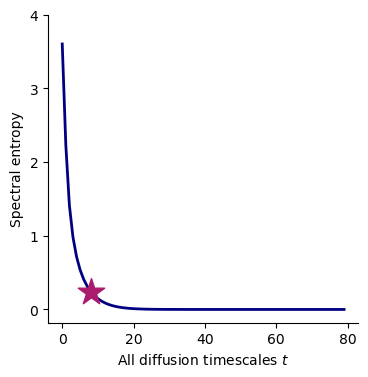

In [38]:
fig,ax=plt.subplots(figsize=(4,4))
ax.plot(all_t[:80], entropies[:80], linewidth=2, c='navy')
ax.scatter([t], [entropies[t]], c='#AA1B6E',marker='*',s=400,zorder=10)
ax.set_xlabel('All diffusion timescales $t$')
ax.set_ylabel('Spectral entropy')
ax.set_yticks([0, 1, 2, 3, 4])
sns.despine()
plt.savefig('ccn_plots/dse.pdf', bbox_inches = "tight",transparent=True, format='pdf')


In [119]:
ide.compute_tphate_SE(np.nan_to_num(data_arr))

3.649884160020849

In [121]:
ide.compute_phate_SE(np.nan_to_num(data_arr))

4.052526235433712

In [123]:
from skdim import id
id.FisherS().fit_transform(np.nan_to_num(data_arr))

10.745786856047442

In [130]:
id.MiND_ML().fit_transform(mod.diff_op)

5.750557228212931

In [147]:
from sklearn.decomposition import PCA

p = PCA()
p.fit(np.nan_to_num(mod.diff_op))

PCA()

In [142]:
id.lPCA().fit_transform(np.nan_to_num(data_arr))

17

In [141]:
id.lPCA().fit_transform(mod.diff_op)

21

In [148]:
np.sum(np.cumsum(p.explained_variance_ratio_) <=0.92)

21

Calculating PHATE...
  Running PHATE on 93 observations and 216 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
  Calculated graph and diffusion operator in 0.01 seconds.
  Calculating optimal t...
    Automatically selected t = 20
  Calculated optimal t in 0.03 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...
  Calculated metric MDS in 0.01 seconds.
Calculated PHATE in 0.09 seconds.
Calculating optimal t...
  Automatically selected t = 20
Calculated optimal t in 0.02 seconds.


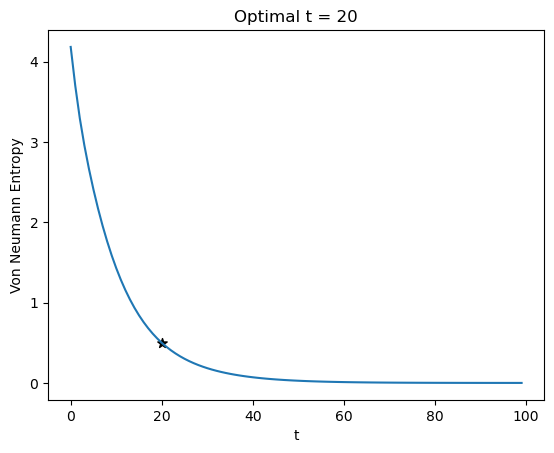

20

In [120]:
pmod = phate.PHATE()
_ = pmod.fit_transform(np.nan_to_num(data_arr))
pmod._find_optimal_t(plot=True)

In [1]:
mod._find_optimal_t(plot=True)

NameError: name 'mod' is not defined

## plot difference maps


In [21]:
mickey_se = np.load(f'{RM_RESULTS_DIR}/aggregated_npy/MICKEY_TPHATE_SE_at_t_all_subjects_results.npy')
aeronaut_se = np.load(f'{RM_RESULTS_DIR}/aggregated_npy/AERONAUT_TPHATE_SE_at_t_all_subjects_results.npy')
mickey_t = np.load(f'{RM_RESULTS_DIR}/aggregated_npy/MICKEY_optt_all_subjects_results.npy')
aeronaut_t = np.load(f'{RM_RESULTS_DIR}/aggregated_npy/AERONAUT_optt_all_subjects_results.npy')


In [38]:
from scipy.spatial.distance import cdist
a = 1-cdist(mickey_se, mickey_t, 'correlation')

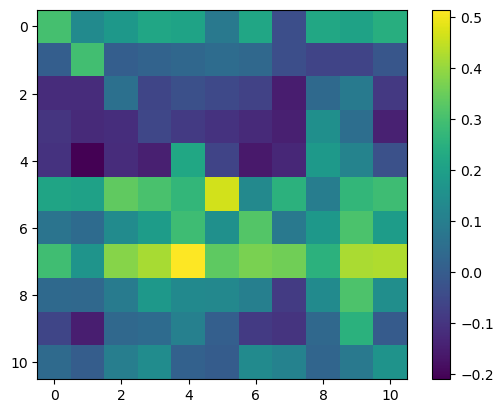

In [39]:
plt.imshow(a,) #cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

In [46]:
x=np.mean(mickey_t,axis=0)
y=np.mean(mickey_se, axis=0)
stats.pearsonr(x,y)

(0.3668059755382332, 0.0)

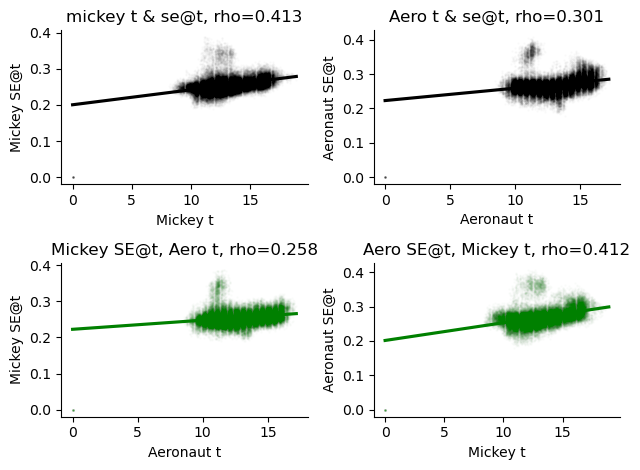

In [49]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()

mmt = np.mean(mickey_t,axis=0)
mmse = np.mean(mickey_se, axis=0)
aerot = np.mean(aeronaut_t,axis=0)
aerose = np.mean(aeronaut_se, axis=0)

g = sns.regplot(x=mmt, y=mmse,  color='k', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[0])
r,p = stats.spearmanr(mmt,mmse)
g.set( xlabel='Mickey t', ylabel='Mickey SE@t', title=f'mickey t & se@t, rho={np.round(r, 3)}')

g = sns.regplot(x=aerot, y=aerose,  color='k', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[1])
r,p = stats.spearmanr(aerot,aerose)
g.set( xlabel='Aeronaut t', ylabel='Aeronaut SE@t', title=f'Aero t & se@t, rho={np.round(r, 3)}')

g = sns.regplot(x=aerot, y=mmse,  color='g', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[2])
r,p = stats.spearmanr(aerot,mmse)
g.set( xlabel='Aeronaut t', ylabel='Mickey SE@t', title=f'Mickey SE@t, Aero t, rho={np.round(r, 3)}')

g = sns.regplot(x=mmt, y=aerose,  color='g', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[3])
r,p = stats.spearmanr(mmt,aerose)
g.set(ylabel='Aeronaut SE@t', xlabel='Mickey t', title=f'Aero SE@t, Mickey t, rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


In [ ]:
dataset = 'rest_movie'
tasks = ['MICKEY','AERONAUT','REST']
all_subjects = RM_SUBJECTS
metrics = 
for meth in ['lPCA''optt']:
    

# aggregate and plot surface results

In [7]:
mask = utils.get_intersect_mask()
cmap = utils.get_brain_cmap()

In [2]:
# plot results - ISC 

nii = {}
for t in RM_DATA_DIRS.keys():
    fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/ISC/LOSO/*{t.lower().capitalize()}*ISC*.nii.gz'))
    print(f'found {len(fns)} for {t}')
    temp = np.zeros(mask.shape)
    for i, f in enumerate(fns):
        d = nib.load(f).get_fdata()
        temp = np.add(temp, d)
    temp /= len(fns)
    n = Nifti1Image(temp, affine=mask.affine)
    nib.save(n, f'{RM_RESULTS_DIR}/ISC/group_average_{t.upper()}_ISC_whole_brain_SL_rad5.nii.gz')
    plot_fn = f'RestMovie/plots/group_average_{t.upper()}_ISC_whole_brain_SL_rad5.png'
    plotting.plot_img_on_surf(n, 
                              views=['lateral','medial'], 
                              cmap=cmap, 
                              inflate=True, 
                              bg_on_data=False, 
                                      alpha=0.8,
                              output_file=plot_fn,
                              darkness=0.8, 
                              threshold=0.1,
                              vmax=0.6, title=f'{t} ISC',
                             )
    plt.close()
    print(plot_fn)

found 11 for REST
RestMovie/plots/group_average_REST_ISC_whole_brain_SL_rad5.png
found 11 for AERONAUT
RestMovie/plots/group_average_AERONAUT_ISC_whole_brain_SL_rad5.png
found 11 for MICKEY
RestMovie/plots/group_average_MICKEY_ISC_whole_brain_SL_rad5.png


In [3]:
for t in RM_DATA_DIRS.keys():
    for tp in ['optt','autocorr']:
        fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/TPHATE_optt/LOSO/*{t.lower().capitalize()}*{tp}*.nii.gz'))
        print(f'found {len(fns)} for {t}')
        temp = np.zeros(mask.shape)
        for i, f in enumerate(fns):
            d = nib.load(f).get_fdata()
            temp = np.add(temp, d)
        temp /= len(fns)
        n = Nifti1Image(temp, affine=mask.affine)
        nib.save(n, f'{RM_RESULTS_DIR}/TPHATE_optt/group_average_{t.upper()}_tphate_{tp}_whole_brain_SL_rad5.nii.gz')
        plot_fn = f'RestMovie/plots/group_average_{t.upper()}_tphate_{tp}_whole_brain_SL_rad5.png'
        plotting.plot_img_on_surf(n, 
                                  views=['lateral','medial'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=plot_fn,
                                  darkness=0.8, 
                                  threshold=1, title=f'{t} tphate {tp}',
                                 )
        plt.close()
        print(plot_fn)

found 11 for REST
RestMovie/plots/group_average_REST_tphate_optt_whole_brain_SL_rad5.png
found 11 for REST
RestMovie/plots/group_average_REST_tphate_autocorr_whole_brain_SL_rad5.png
found 11 for AERONAUT
RestMovie/plots/group_average_AERONAUT_tphate_optt_whole_brain_SL_rad5.png
found 11 for AERONAUT
RestMovie/plots/group_average_AERONAUT_tphate_autocorr_whole_brain_SL_rad5.png
found 11 for MICKEY
RestMovie/plots/group_average_MICKEY_tphate_optt_whole_brain_SL_rad5.png
found 11 for MICKEY
RestMovie/plots/group_average_MICKEY_tphate_autocorr_whole_brain_SL_rad5.png


In [ ]:
for t in RM_DATA_DIRS.keys():
    for tp in ide.METHOD_NAMES:
        fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/IDE/LOSO/*{t.lower().capitalize()}*_{tp}*.nii.gz'))
        print(f'found {len(fns)} for {t} {tp}')
        temp = np.zeros(mask.shape)
        for i, f in enumerate(fns):
            d = nib.load(f).get_fdata()
            temp = np.add(temp, d)
        temp /= len(fns)
        n = Nifti1Image(temp, affine=mask.affine)
        nib.save(n, f'{RM_RESULTS_DIR}/IDE/group_average_{t.upper()}_ide_{tp}_whole_brain_SL_rad5.nii.gz')
        plot_fn = f'RestMovie/plots/group_average_{t.upper()}_ide_{tp}_whole_brain_SL_rad5.png'
        plotting.plot_img_on_surf(n, 
                                  views=['lateral','medial'], 
                                  cmap=cmap, 
                                  inflate=True, 
                                  bg_on_data=False, 
                                          alpha=0.8,
                                  output_file=plot_fn,
                                  darkness=0.8, 
                                  threshold=1, title=f'{t} {tp}',
                                 )
        plt.close()
        print(plot_fn)

found 11 for REST CorrInt
RestMovie/plots/group_average_REST_ide_CorrInt_whole_brain_SL_rad5.png
found 11 for REST DIFF_MAP_SE
RestMovie/plots/group_average_REST_ide_DIFF_MAP_SE_whole_brain_SL_rad5.png
found 11 for REST FisherS
RestMovie/plots/group_average_REST_ide_FisherS_whole_brain_SL_rad5.png
found 11 for REST KNN
RestMovie/plots/group_average_REST_ide_KNN_whole_brain_SL_rad5.png
found 11 for REST MLE
RestMovie/plots/group_average_REST_ide_MLE_whole_brain_SL_rad5.png
found 11 for REST MiND_ML
RestMovie/plots/group_average_REST_ide_MiND_ML_whole_brain_SL_rad5.png
found 11 for REST PHATE_SE
RestMovie/plots/group_average_REST_ide_PHATE_SE_whole_brain_SL_rad5.png
found 11 for REST TPHATE_SE
RestMovie/plots/group_average_REST_ide_TPHATE_SE_whole_brain_SL_rad5.png
found 11 for REST lPCA
RestMovie/plots/group_average_REST_ide_lPCA_whole_brain_SL_rad5.png
found 11 for AERONAUT CorrInt
RestMovie/plots/group_average_AERONAUT_ide_CorrInt_whole_brain_SL_rad5.png
found 11 for AERONAUT DIFF_MAP

In [62]:
# aggregate results
coords = np.where(mask.get_fdata() == 1)
# start with ISC
for t in RM_DATA_DIRS.keys():
    fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/ISC/LOSO/*{t.lower().capitalize()}*ISC*.nii.gz'))
    print(f'found {len(fns)} for {t} ISC')
    results_vecs = []
    for f in fns:
        x = nib.load(f).get_fdata()
        vec = x[coords[0][:], coords[1][:], coords[2][:]]
        results_vecs.append(vec)
    r = np.array(results_vecs)
    print(r.shape)
    np.save(f'{RM_RESULTS_DIR}/aggregate_npy/{t.upper()}_ISC_all_subjects_results.npy', r)

found 11 for REST ISC
(11, 70958)


FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/milgram/project/turk-browne/users/elb77//task_dim/RestMovie/results/aggregate_npy/REST_ISC_all_subjects_results.npy'

In [199]:
#'PHATE_SE_at_t','TPHATE_SE_at_t','TPHATE_FisherS','PHATE_FisherS','DIFF_MAP_FisherS'

avg_isc_mickey = np.mean(np.load(f'{RM_RESULTS_DIR}/ISC/MICKEY_ISC_all_subjects_results.npy'),axis=0)
avg_isc_aeronaut = np.mean(np.load(f'{RM_RESULTS_DIR}/ISC/AERONAUT_ISC_all_subjects_results.npy'),axis=0)

avg_mickey = np.mean(np.load(f'{RM_RESULTS_DIR}/aggregated_npy/MICKEY_DIFF_MAP_FisherS_all_subjects_results.npy'),axis=0)
avg_aeronaut = np.mean(np.load(f'{RM_RESULTS_DIR}/aggregated_npy/AERONAUT_DIFF_MAP_FisherS_all_subjects_results.npy'),axis=0)

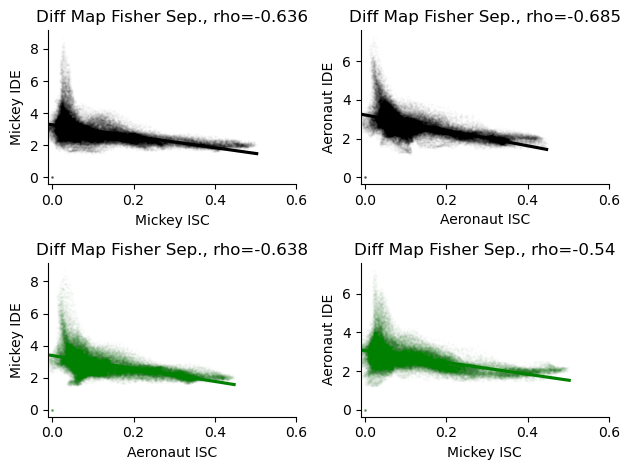

In [200]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()

g = sns.regplot(x=avg_isc_mickey, y=avg_mickey,  color='k', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[0])
r,p = stats.spearmanr(avg_isc_mickey,avg_mickey)
g.set(xlim=[-0.01, 0.6], xlabel='Mickey ISC', ylabel='Mickey IDE', title=f'Diff Map Fisher Sep., rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_aeronaut,  color='k', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[1])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_aeronaut)
g.set(xlim=[-0.01, 0.6], xlabel='Aeronaut ISC', ylabel='Aeronaut IDE', title=f'Diff Map Fisher Sep., rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_mickey,  color='g', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[2])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_mickey)
g.set(xlim=[-0.01, 0.6], xlabel='Aeronaut ISC', ylabel='Mickey IDE', title=f'Diff Map Fisher Sep., rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_mickey, y=avg_aeronaut,  color='g', order=1, scatter_kws={'alpha':0.01, 's':1}, ax=ax[3])
r,p = stats.spearmanr(avg_isc_mickey,avg_aeronaut)
g.set(xlim=[-0.01, 0.6], xlabel='Mickey ISC', ylabel='Aeronaut IDE', title=f'Diff Map Fisher Sep., rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

Xtrain = avg_isc_mickey[:60000].reshape(-1,1)
Xtest = avg_isc_mickey[60000:].reshape(-1,1)
ytrain = avg_optt_mickey[:60000].reshape(-1,1)
ytest = avg_optt_mickey[60000:].reshape(-1,1)
#Edit: added second square bracket above to fix the ValueError problem

poly = PolynomialFeatures(degree=1)
Xtrain_ = poly.fit_transform(Xtrain)
predict_ = poly.fit_transform(ytrain)

clf = linear_model.LinearRegression()
clf.fit(Xtrain_, predict_)


print(clf.score(poly.fit_transform(Xtest), poly.fit_transform(ytest)))

0.6369461106709784


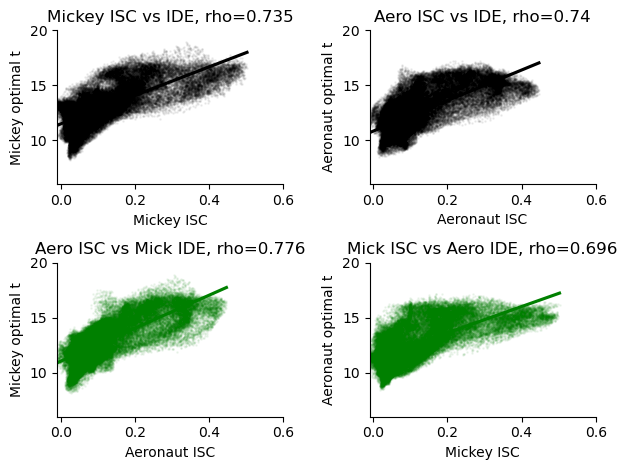

In [50]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()


g = sns.regplot(x=avg_isc_mickey, y=avg_optt_mickey,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[0])
r,p = stats.spearmanr(avg_isc_mickey,avg_optt_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[6,20], xlabel='Mickey ISC', ylabel='Mickey optimal t', title=f'Mickey ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_optt_aeronaut,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[1])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_optt_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[6,20], xlabel='Aeronaut ISC', ylabel='Aeronaut optimal t', title=f'Aero ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_optt_mickey,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[2])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_optt_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[6,20], xlabel='Aeronaut ISC', ylabel='Mickey optimal t', title=f'Aero ISC vs Mick IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_mickey, y=avg_optt_aeronaut,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[3])
r,p = stats.spearmanr(avg_isc_mickey,avg_optt_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[6,20], xlabel='Mickey ISC', ylabel='Aeronaut optimal t', title=f'Mick ISC vs Aero IDE, rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


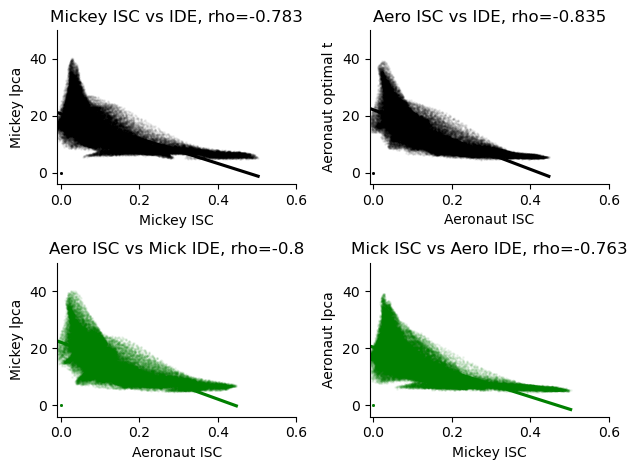

In [57]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()


g = sns.regplot(x=avg_isc_mickey, y=avg_lpca_mickey,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[0])
r,p = stats.spearmanr(avg_isc_mickey,avg_lpca_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[-4,50], xlabel='Mickey ISC', ylabel='Mickey lpca', title=f'Mickey ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_lpca_aeronaut,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[1])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_lpca_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[-4,50], xlabel='Aeronaut ISC', ylabel='Aeronaut lpca', title=f'Aero ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_lpca_mickey,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[2])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_lpca_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[-4,50], xlabel='Aeronaut ISC', ylabel='Mickey lpca', title=f'Aero ISC vs Mick IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_mickey, y=avg_lpca_aeronaut,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[3])
r,p = stats.spearmanr(avg_isc_mickey,avg_lpca_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[-4,50], xlabel='Mickey ISC', ylabel='Aeronaut lpca', title=f'Mick ISC vs Aero IDE, rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


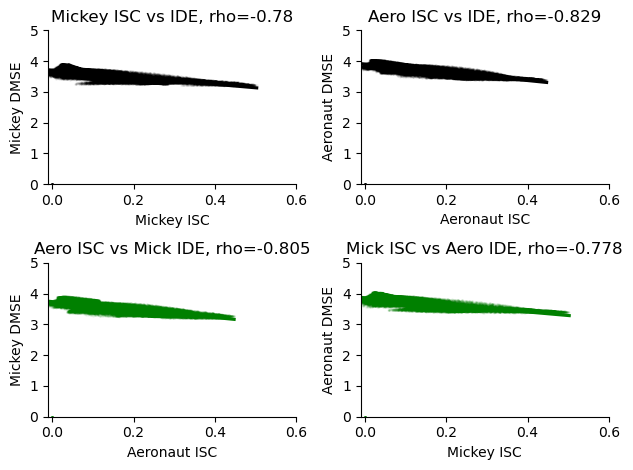

In [60]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()


g = sns.regplot(x=avg_isc_mickey, y=avg_diff_se_mickey,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[0])
r,p = stats.spearmanr(avg_isc_mickey,avg_diff_se_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Mickey ISC', ylabel='Mickey DMSE', title=f'Mickey ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_diff_se_aeronaut,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[1])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_diff_se_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[-0,5], xlabel='Aeronaut ISC', ylabel='Aeronaut DMSE', title=f'Aero ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_diff_se_mickey,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[2])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_diff_se_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Aeronaut ISC', ylabel='Mickey DMSE', title=f'Aero ISC vs Mick IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_mickey, y=avg_diff_se_aeronaut,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[3])
r,p = stats.spearmanr(avg_isc_mickey,avg_diff_se_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Mickey ISC', ylabel='Aeronaut DMSE', title=f'Mick ISC vs Aero IDE, rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


In [ ]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()


g = sns.regplot(x=avg_isc_mickey, y=avg_tph_se_mickey,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[0])
r,p = stats.spearmanr(avg_isc_mickey,avg_tph_se_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Mickey ISC', ylabel='Mickey DMSE', title=f'Mickey ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_tph_se_aeronaut,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[1])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_tph_se_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[-0,5], xlabel='Aeronaut ISC', ylabel='Aeronaut DMSE', title=f'Aero ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_tph_se_mickey,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[2])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_tph_se_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Aeronaut ISC', ylabel='Mickey DMSE', title=f'Aero ISC vs Mick IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_mickey, y=avg_tph_se_aeronaut,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[3])
r,p = stats.spearmanr(avg_isc_mickey,avg_tph_se_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Mickey ISC', ylabel='Aeronaut DMSE', title=f'Mick ISC vs Aero IDE, rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


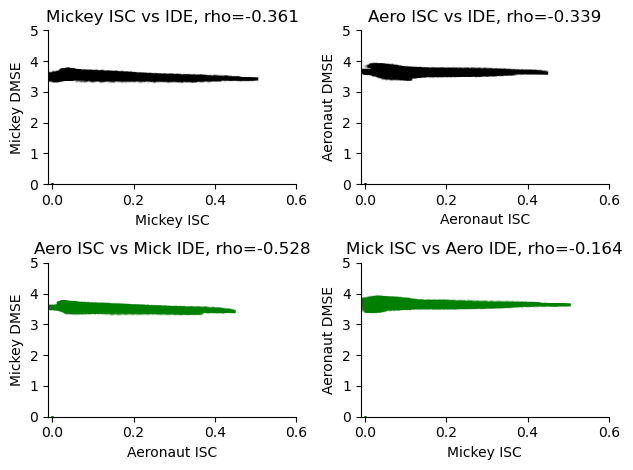

In [61]:
fig,ax = plt.subplots(2,2)
ax=ax.ravel()


g = sns.regplot(x=avg_isc_mickey, y=avg_tph_se_mickey,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[0])
r,p = stats.spearmanr(avg_isc_mickey,avg_tph_se_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Mickey ISC', ylabel='Mickey DMSE', title=f'Mickey ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_tph_se_aeronaut,  color='k', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[1])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_tph_se_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[-0,5], xlabel='Aeronaut ISC', ylabel='Aeronaut DMSE', title=f'Aero ISC vs IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_aeronaut, y=avg_tph_se_mickey,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[2])
r,p = stats.spearmanr(avg_isc_aeronaut,avg_tph_se_mickey)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Aeronaut ISC', ylabel='Mickey DMSE', title=f'Aero ISC vs Mick IDE, rho={np.round(r, 3)}')

g = sns.regplot(x=avg_isc_mickey, y=avg_tph_se_aeronaut,  color='g', order=1, scatter_kws={'alpha':0.05, 's':1}, ax=ax[3])
r,p = stats.spearmanr(avg_isc_mickey,avg_tph_se_aeronaut)
g.set(xlim=[-0.01, 0.6], ylim=[0,5], xlabel='Mickey ISC', ylabel='Aeronaut DMSE', title=f'Mick ISC vs Aero IDE, rho={np.round(r, 3)}')

sns.despine()

fig.tight_layout()


## FUCKING AROUND TRYING TO DEBUG STUFF

In [115]:
data_masked

{'REST': array([], shape=(0, 72, 60), dtype=float64),
 'AERONAUT': array([], shape=(0, 72, 60), dtype=float64),
 'MICKEY': array([], shape=(0, 72, 60), dtype=float64)}

In [3]:
# difference between tasks
from scipy.stats import ttest_1samp

ALL_SUBJECTS = utils.get_intersecting_subjects(subject_filter=0)
RESULT_DIR = utils.get_results_dir()
BRAIN_MASK = utils.get_intersect_mask(subject_filter=0)

SL_RAD = 5
mask = BRAIN_MASK
masker_wb = NiftiMasker(mask_img=mask, standardize=False)

TASKS = RM_DATA_DIRS.keys()
coords = np.where(mask.get_fdata()==1)
print(np.shape(coords))
difference_volumes = {"REST-AERONAUT":[], "REST-MICKEY":[], "AERONAUT-MICKEY":[]}

for sub in RM_SUBJECTS:
    data_masked = {}
    for task in TASKS:
        nii = nib.load(f'{RM_RESULTS_DIR}/TPHATE_optt/LOSO/{sub}_{task.lower().capitalize()}_tphate_optt_whole_brain_SL_rad5.nii.gz')
        vol = nii.get_fdata()
        masked = vol[coords]
        data_masked[task] = masked
    
    for task_pair in [("REST","AERONAUT")]:, #("REST","MICKEY"), ("AERONAUT","MICKEY")]:
        d0, d1 = data_masked[task_pair[0]], data_masked[task_pair[1]]
        string=f'{task_pair[0]}-{task_pair[1]}'
        #outfn = f'{res_dir}/sub-{sub:02d}_{string}_diff_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz'
        diff = d0 - d1
        difference_volumes[string].append(diff)
        #out_vol = np.zeros_like(mask)
        #out_vol[coords] = diff
        print(sub, task_pair, np.nanmin(diff), np.round(np.nanmean(diff),2), np.nanmax(diff))
        #nii_res = nib.Nifti1Image(out_vol, nii.affine)
        #nii_res.header.set_zooms(nii.header.get_zooms())
        #nib.save(nii_res, outfn) 

# tstats, pvals, means, medians = {}, {}, {}, {}
# for key, value in difference_volumes.items():
#     difference_volumes[key] = np.nan_to_num(np.array(value))
#     t, p = ttest_1samp(difference_volumes[key], popmean=0, axis=0)
#     tstats[key]=t
#     pvals[key]=p
#     m=np.mean(np.nan_to_num(np.array(value)), axis=0)
#     means[key]=m
#     med=np.median(np.nan_to_num(np.array(value)), axis=0)
#     medians[key]=med
#     for val, typ in zip([t, p, m, med], ['tstat','pvalue','average','median']):
#         # out_vol = np.zeros_like(mask)
#         # out_vol[coords] = val
#         outfn = f'./RestMovie/results/AGGREGATE/{key}_diff_{typ}_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz'
#         #nii_res = nib.Nifti1Image(out_vol, nii.affine)
#         #nii_res.header.set_zooms(nii.header.get_zooms())
#         #nib.save(nii_res, outfn)
#         print(outfn, np.round(np.nanmean(val),2) )

(3, 70958)
rest_movie_01 ('REST', 'AERONAUT') -23.0 -9.66 5.0
rest_movie_01 ('REST', 'MICKEY') -15.0 -3.95 9.0
rest_movie_01 ('AERONAUT', 'MICKEY') -4.0 5.71 17.0
rest_movie_02 ('REST', 'AERONAUT') -7.0 1.94 16.0
rest_movie_02 ('REST', 'MICKEY') -10.0 0.3 13.0
rest_movie_02 ('AERONAUT', 'MICKEY') -14.0 -1.64 12.0
rest_movie_03 ('REST', 'AERONAUT') -14.0 -0.29 12.0
rest_movie_03 ('REST', 'MICKEY') -6.0 2.92 18.0
rest_movie_03 ('AERONAUT', 'MICKEY') -7.0 3.2 16.0
rest_movie_04 ('REST', 'AERONAUT') -9.0 1.38 10.0
rest_movie_04 ('REST', 'MICKEY') -7.0 1.3 10.0
rest_movie_04 ('AERONAUT', 'MICKEY') -7.0 -0.08 10.0
rest_movie_05 ('REST', 'AERONAUT') -13.0 -0.46 13.0
rest_movie_05 ('REST', 'MICKEY') -8.0 1.33 17.0
rest_movie_05 ('AERONAUT', 'MICKEY') -7.0 1.8 14.0
rest_movie_07 ('REST', 'AERONAUT') -10.0 0.44 11.0
rest_movie_07 ('REST', 'MICKEY') -24.0 -1.36 9.0
rest_movie_07 ('AERONAUT', 'MICKEY') -16.0 -1.81 9.0
rest_movie_08 ('REST', 'AERONAUT') -11.0 0.66 12.0
rest_movie_08 ('REST', 'MICKE

In [118]:
for d in vol_diffs:
    print(np.nanmin(d), np.nanmean(d), np.nanmax(d))

-23.0 -9.657938498830294 5.0
-7.0 1.9388934299162885 16.0
-14.0 -0.28864962372107444 12.0
-9.0 1.3842695679134136 10.0
-13.0 -0.46155472251190843 13.0
-10.0 0.44062684968572957 11.0
-11.0 0.6599960540037769 12.0
-2.0 10.43438371994701 28.0
-4.0 3.5852476112630005 16.0
-6.0 3.0474083260520306 12.0
-12.0 -0.8688942754869078 6.0


In [117]:
# run difference maps
from scipy.stats import ttest_1samp

from task_comparison import ttest_vol, run_subtraction
ALL_SUBJECTS = utils.get_intersecting_subjects(subject_filter=0)
RESULT_DIR = utils.get_results_dir()
BRAIN_MASK = utils.get_intersect_mask(subject_filter=0)
task1 = 'REST'
task2 = 'AERONAUT'
metric = 'optt'

# load all task 1 
aero_all = np.load(f'{RESULT_DIR}/TPHATE_optt/AERONAUT_optt_all_subjects_results.npy')
rest_all = np.load(f'{RESULT_DIR}/TPHATE_optt/REST_optt_all_subjects_results.npy')
aero_mean = np.mean(aero_all,axis=0)
rest_mean = np.mean(rest_all,axis=0)
rest_aero = rest_mean - aero_mean
vol_diffs = rest_all - aero_all
print(vol_diffs.shape)

# t,p = ttest_1samp(difference_volumes, popmean=0, axis=0)


(11, 70958)


In [86]:
X = np.zeros_like(BRAIN_MASK.get_fdata())
X[mask_coords] = rest_aero
mean_diff_vol = nib.Nifti1Image(X, affine=BRAIN_MASK.affine)


In [105]:
def vec2vol(values, mask_nii):
    mask_coords = np.where(mask_nii.get_fdata() == 1)
    X = np.zeros_like(mask_nii.get_fdata())
    X[mask_coords] = values
    vol = nib.Nifti1Image(X, affine=mask.affine)
    vol.header.set_zooms(mask.header.get_zooms())
    return vol

def threshold_mask(tcc_img, avg_img):
    # binarize the thresholded image to then apply to the average image
    mask = math_img("img > 0", img=tcc_img)
    thresholded_masked = math_img('img1 * img2', img1=avg_img, img2=mask)
    return thresholded_masked

def mask_pval(original, pvalues, threshold=0.05):
    pval_masked = math_img(f'np.where(img <= {threshold}, 1, 0)', img=pvalues)
    masked_data = math_img(f'img1 * img2', img1=original, img2=pval_masked)
    return masked_data



In [91]:
tmap = vec2vol(t, BRAIN_MASK)
pmap = vec2vol(p, BRAIN_MASK)
rest_aero = 

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

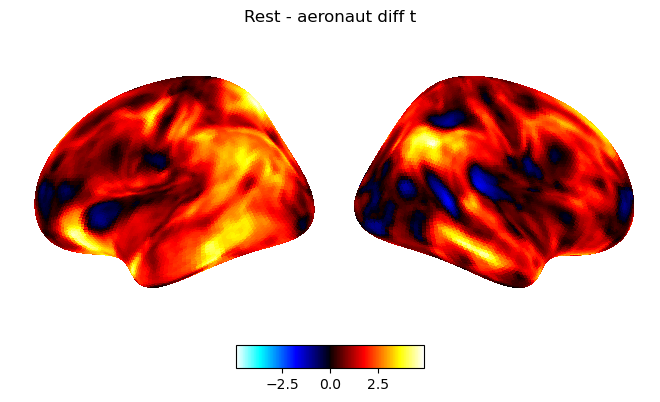

In [106]:
plotting.plot_img_on_surf(mean_diff_vol, views=['lateral'], inflate=True, 
                          threshold=0,  title='Rest - aeronaut diff t')

In [97]:
p

array([nan, nan, nan, ..., nan, nan, nan])

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

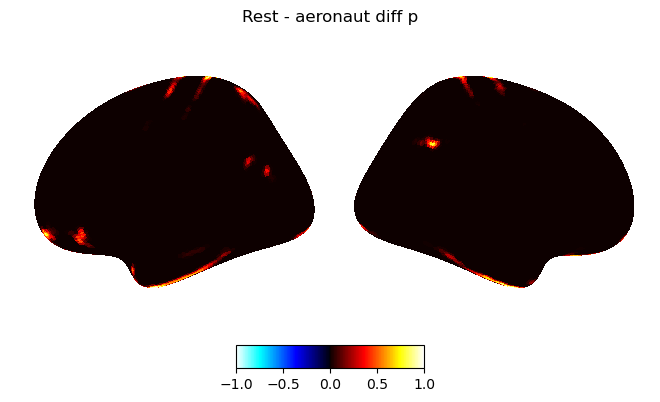

In [96]:
pmap_masked = math_img('np.where(im < 0.05, 1, 0)', im=pmap)
plotting.plot_img_on_surf(pmap_masked, views=['lateral'], inflate=True, 
                          threshold=0, title='Rest - aeronaut diff p')

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

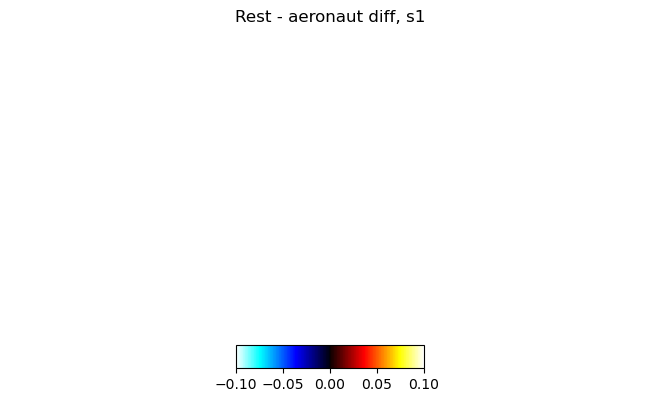

In [90]:
plotting.plot_img_on_surf(thresholded_avg_map, views=['lateral'], inflate=True, 
                          threshold=0,  title='Rest - aeronaut diff, s1')

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

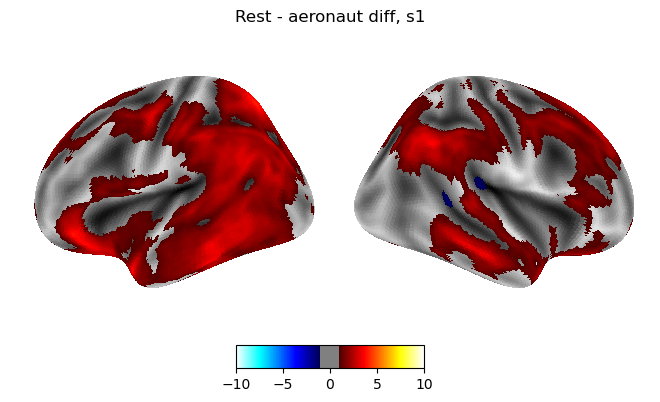

In [77]:
plotting.plot_img_on_surf(mean_diff_vol, views=['lateral'], inflate=True, 
                          threshold=1, vmax=10, title='Rest - aeronaut diff, s1')

In [62]:
from nilearn.image import threshold_img, math_img
# def load_mask_data_file(mask_coords, subject, task, metric, filter_by_age=0, slrad=5):
#     nii = utils.get_metric_nii_subject(subject, task, metric, filter_by_age=filter_by_age, slrad=slrad)
#     # x = nii.get_fdata()
#     # vec = x[mask_coords[0][:], mask_coords[1][:], mask_coords[2][:]]
#     return nii

def imdiff(im1, im2):
    return math_img('img1 - img2', img1=im1, img2=im2)

mask_coords = np.where(BRAIN_MASK.get_fdata() == 1)
task1_list, task2_list, diff = [], [], []
for sub in ALL_SUBJECTS[:4]:
    task1_nii = utils.get_metric_nii_subject(sub, task1,metric)
    task2_nii = utils.get_metric_nii_subject(sub, task2, metric)
    task1_list.append(task1_nii)
    task2_list.append(task2_nii)
    d=imdiff(task1_nii, task2_nii)
    diff.append(d)


(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

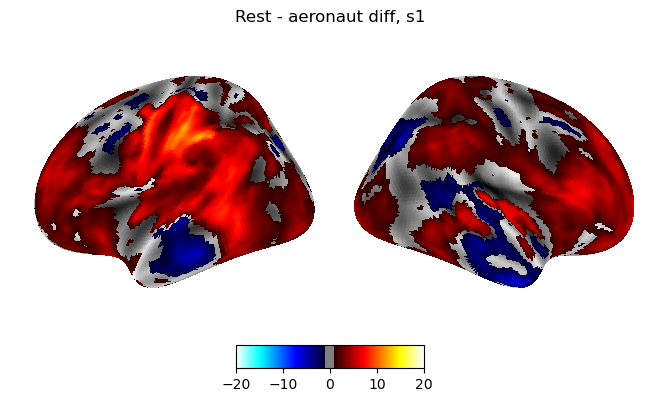

In [67]:
plotting.plot_img_on_surf(diff[1], views=['lateral'], inflate=True, threshold=1, vmax=20, title='Rest - aeronaut diff, s1')

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

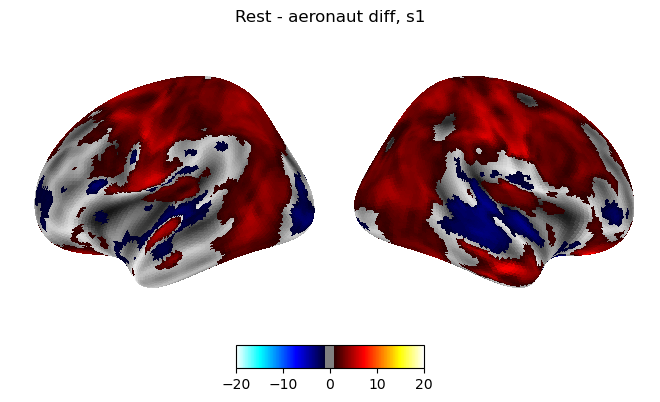

In [69]:
plotting.plot_img_on_surf(diff[3], threshold=1, vmax=20, views=['lateral'], inflate=True, title='Rest - aeronaut diff, s1')

In [52]:
diff = np.array(diff)

In [53]:
diff.shape

(11, 70958)

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

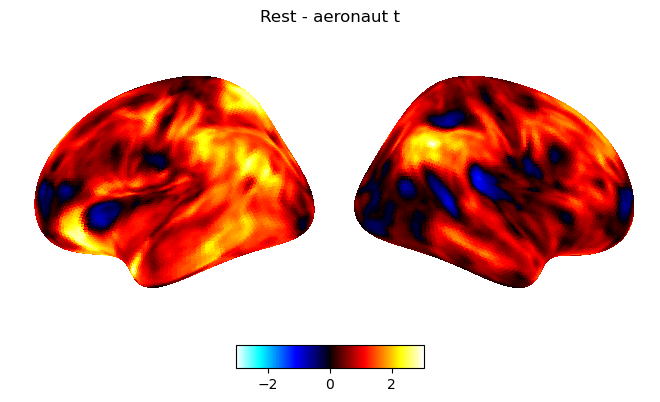

In [29]:
 plotting.plot_img_on_surf(t, threshold=0, views=['lateral'], inflate=True, title='Rest - aeronaut t')

(array([   64.,  1028.,  6969., 16953., 20427., 14328.,  7922.,  2655.,
          560.,    52.]),
 array([-2.45454545, -1.71818182, -0.98181818, -0.24545455,  0.49090909,
         1.22727273,  1.96363636,  2.7       ,  3.43636364,  4.17272727,
         4.90909091]),
 <BarContainer object of 10 artists>)

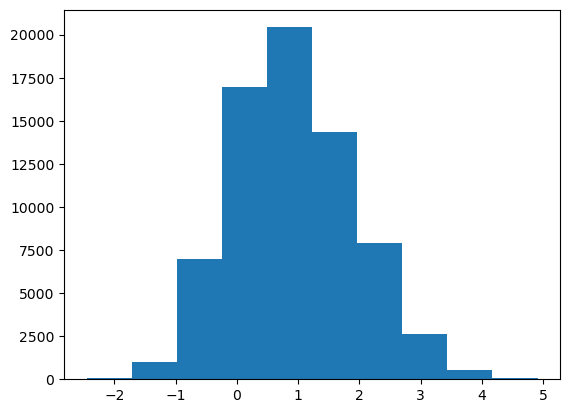

In [34]:
plt.hist(np.mean(diff_vols,axis=0))

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

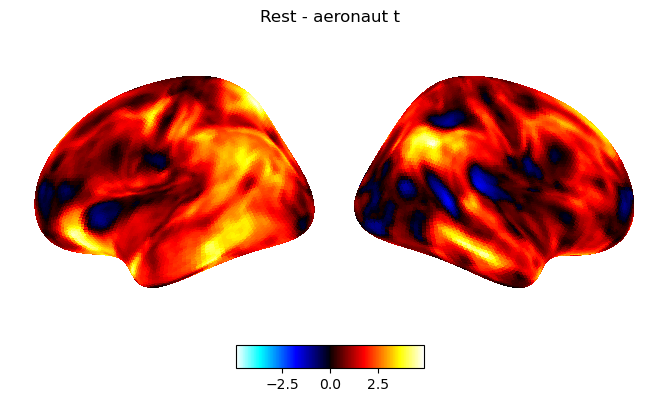

In [30]:
 plotting.plot_img_on_surf(mu, threshold=0, views=['lateral'], 
                           inflate=True, title='Rest - aeronaut mean')

In [22]:
plotting.plot_img_on_surf(t, threshold=0.1, views=['lateral'], inflate=True, title='Rest - mickey t'

500

In [4]:
pwd

'/gpfs/milgram/pi/turk-browne/users/elb77/task_dim'

In [6]:
string = f'python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/task_comparison.py '

with open('joblists/task_comparison_joblist.txt','w') as f:
    for dataset in ['rest_movie','narratives','camcan']:
        for method in ['optt','autocorr']+ide.METHOD_NAMES:
            if dataset == 'camcan':
                s=35
            else:
                s=0
            f.write(f'{string} -d {dataset} -m {method} -o 1 --plot 1 -s {s}\n')    


In [25]:
ps = np.arange(0, 1, 0.0001)
c = np.where(ps < 0.05)
exp = np.log(ps)
exp[c]

array([       -inf, -9.21034037, -8.51719319, -8.11172808, -7.82404601,
       -7.60090246, -7.4185809 , -7.26443022, -7.13089883, -7.01311579,
       -6.90775528, -6.8124451 , -6.72543372, -6.64539101, -6.57128304,
       -6.50229017, -6.43775165, -6.37712703, -6.31996861, -6.26590139,
       -6.2146081 , -6.16581793, -6.11929792, -6.07484616, -6.03228654,
       -5.99146455, -5.95224383, -5.91450351, -5.87813586, -5.84304454,
       -5.80914299, -5.77635317, -5.74460447, -5.71383281, -5.68397985,
       -5.65499231, -5.62682143, -5.59942246, -5.57275421, -5.54677873,
       -5.52146092, -5.49676831, -5.47267075, -5.44914026, -5.42615074,
       -5.40367788, -5.38169898, -5.36019277, -5.33913936, -5.31852007,
       -5.29831737, -5.27851474, -5.25909665, -5.24004846, -5.22135633,
       -5.20300719, -5.18498868, -5.1672891 , -5.14989736, -5.13280293,
       -5.11599581, -5.09946651, -5.08320599, -5.06720565, -5.05145729,
       -5.0359531 , -5.02068563, -5.00564775, -4.99083267, -4.97

In [ ]:
thresholded_image=threshold_img(
        mu,
        threshold=threshold_criteria,
        cluster_threshold=cluster_criteria,
        two_sided=True,
    )

(<Figure size 640x480 with 3 Axes>,
 [<Axes3DSubplot:>, <Axes3DSubplot:>, <AxesSubplot:>])

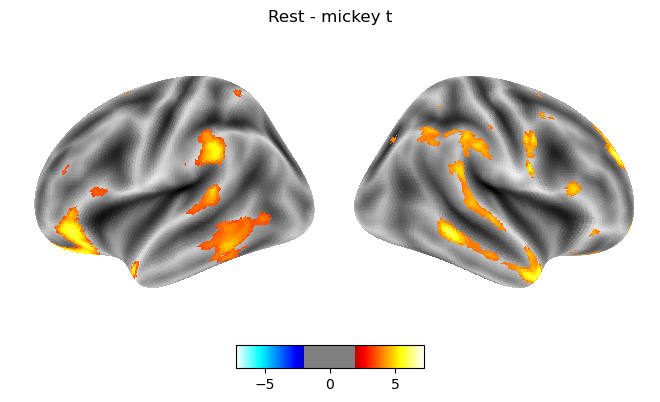

In [27]:
 plotting.plot_img_on_surf(p, threshold=1.96, views=['lateral'], inflate=True, title='Rest - mickey t')

In [6]:
# aggregate results
coords = np.where(mask.get_fdata() == 1)
# start with ISC
for t in RM_DATA_DIRS.keys():
    for tp in ['optt','autocorr']:
        fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/TPHATE_optt/LOSO/*{t.lower().capitalize()}*_{tp}*.nii.gz'))
        print(f'found {len(fns)} for {t} {tp}')
        results_vecs = []
        for f in fns:
            x = nib.load(f).get_fdata()
            vec = x[coords[0][:], coords[1][:], coords[2][:]]
            results_vecs.append(vec)
        r = np.array(results_vecs)
        print(r.shape)
        np.save(f'{RM_RESULTS_DIR}/TPHATE_optt/{t.upper()}_{tp}_all_subjects_results.npy', r)

found 11 for REST optt
(11, 70958)
found 11 for REST autocorr
(11, 70958)
found 11 for AERONAUT optt
(11, 70958)
found 11 for AERONAUT autocorr
(11, 70958)
found 11 for MICKEY optt
(11, 70958)
found 11 for MICKEY autocorr
(11, 70958)


In [3]:
# aggregate results for subjects and all methods

df_list = []

for t in RM_DATA_DIRS.keys():
    # load in IDE results
    for tp in ide.METHOD_NAMES:
        res = np.load(f'{RM_RESULTS_DIR}/IDE/{t.upper()}_{tp}_all_subjects_results.npy')
        for i in range(res.shape[0]):
            subject = i+1
            temp = pd.DataFrame()
            temp['score']=res[i].T
            temp['subject']=subject
            temp['task']=t
            temp['metric']=tp
            temp['sl_idx']=np.arange(res.shape[1])
            df_list.append(temp)
    
    for tp in ['optt','autocorr']:
        res = np.load(f'{RM_RESULTS_DIR}/TPHATE_optt/{t.upper()}_{tp}_all_subjects_results.npy')
        for i in range(res.shape[0]):
            subject = i+1
            temp = pd.DataFrame()
            temp['score']=res[i].T
            temp['subject']=subject
            temp['task']=t
            temp['metric']=tp
            temp['sl_idx']=np.arange(res.shape[1])
            df_list.append(temp)
    
    tp = 'ISC'
    res = np.load(f'{RM_RESULTS_DIR}/ISC/{t.upper()}_{tp}_all_subjects_results.npy')
    for i in range(res.shape[0]):
        subject = i+1
        temp = pd.DataFrame()
        temp['score']=res[i].T
        temp['subject']=subject
        temp['task']=t
        temp['metric']=tp
        temp['sl_idx']=np.arange(res.shape[1])
        df_list.append(temp)
df = pd.concat(df_list)

In [4]:
df.to_csv('RestMovie/aggregated_searchlight_results.csv')
mean_df = df.groupby(['task','sl_idx','metric']).mean().reset_index()
std_df = df.groupby(['task','sl_idx','metric']).std().reset_index()

In [6]:
df = pd.read_csv('RestMovie/aggregated_searchlight_results.csv')

In [8]:
stat_df = mean_df
stat_df["stdev"]=std_df['score'].values
stat_df["mean"]=mean_df['score'].values


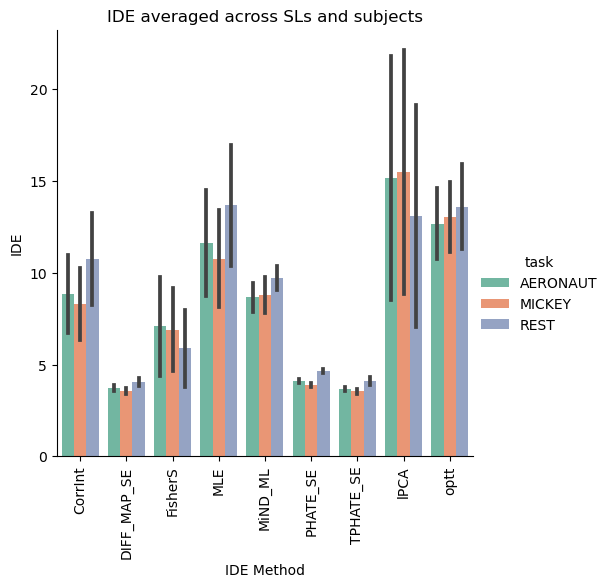

In [20]:
order = sorted(ide.METHOD_NAMES+['optt'])
order.remove("KNN")
g=sns.catplot(kind='bar', hue='task', x='metric', y='mean', data=stat_df, ci='sd', order=order,palette='Set2')
g.set(xlabel='IDE Method',ylabel='IDE',title='IDE averaged across SLs and subjects')
g.set_xticklabels(rotation=90)


In [3]:
## load in just the numpy files
task = 'AERONAUT'
aero_results = {}
for tp in ide.METHOD_NAMES:
    res = np.load(f'{RM_RESULTS_DIR}/IDE/{task}_{tp}_all_subjects_results.npy')
    aero_results[tp] = res

task = 'REST'
rest_results = {}
for tp in ide.METHOD_NAMES:
    res = np.load(f'{RM_RESULTS_DIR}/IDE/{task}_{tp}_all_subjects_results.npy')
    rest_results[tp] = res

task = 'MICKEY'
mickey_results = {}
for tp in ide.METHOD_NAMES:
    res = np.load(f'{RM_RESULTS_DIR}/IDE/{task}_{tp}_all_subjects_results.npy')
    mickey_results[tp] = res



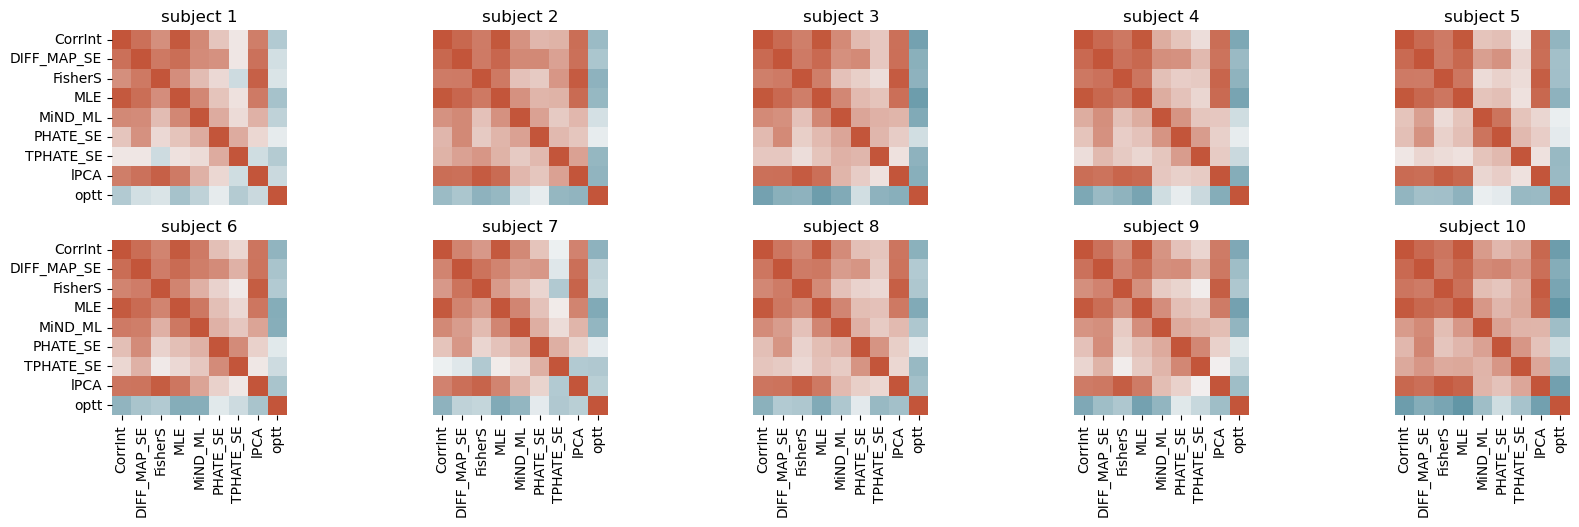

In [69]:
# correlate within subject across methods
order = ['CorrInt','FisherS','MLE','MiND_ML','lPCA','optt','DIFF_MAP_SE','PHATE_SE','TPHATE_SE']
task = 'REST'
fig,ax=plt.subplots(2,5,figsize=(20,5))
ax=ax.ravel()
vals = df[(df['task']==task) & (df['metric']).isin(order)] 
#v['subject_metric'] = v['subject'].astype(str) + '_' + df['metric']
cmap = sns.diverging_palette(220, 20, as_cmap=True)
for s in range(1,11):
    
    v = vals[vals['subject'] == s][['metric','score','sl_idx']]
    
    xtl, ytl = False, False
    if s == 1 or s == 6: ytl = True
    if s >= 6: xtl = True
    
    g=sns.heatmap(v.pivot(index='sl_idx', columns='metric', values='score').corr(), vmin=-1, vmax=1, cmap=cmap,
                  ax=ax[s-1],cbar=False, square=True, xticklabels=xtl, yticklabels=ytl)
    
    g.set(title=f'subject {s}',xlabel="", ylabel="")
    

In [39]:
#vals = df[(df['task']==task) & (df['subject'].isin([1,2,3])) & (df['metric']).isin(order)]


v = vals[['subject', 'metric','score','sl_idx']]
v['subject_metric'] = v['subject'].astype(str) + '_' + df['metric']

In [ ]:
v.pivot(index='sl_idx', columns='subject_metric', values='score').corr()

subject_metric,1_CorrInt,1_DIFF_MAP_SE,1_FisherS,1_MLE,1_MiND_ML,1_PHATE_SE,1_TPHATE_SE,1_lPCA,1_optt,2_CorrInt,...,2_optt,3_CorrInt,3_DIFF_MAP_SE,3_FisherS,3_MLE,3_MiND_ML,3_PHATE_SE,3_TPHATE_SE,3_lPCA,3_optt
subject_metric,,,,,,,,,,,,,,,,,,,,,
1_CorrInt,1.000000,0.060787,0.058193,0.510437,0.400565,0.176829,0.033058,0.230200,-0.211078,0.414967,...,-0.522175,0.317894,0.270769,0.176307,0.321609,0.266981,0.202321,0.410664,0.208279,-0.366811
1_DIFF_MAP_SE,0.060787,1.000000,0.204286,0.090502,0.351981,0.923749,0.498655,0.150946,0.272759,-0.009483,...,0.120063,0.059132,0.418923,0.088158,0.052950,0.104330,0.857145,0.372193,0.068351,0.113308
1_FisherS,0.058193,0.204286,1.000000,0.036238,0.047758,0.182121,0.312329,0.689038,0.393886,-0.045495,...,0.006160,-0.075806,-0.042409,-0.135104,-0.089643,0.043693,0.135365,0.148161,-0.117574,0.085912
1_MLE,0.510437,0.090502,0.036238,1.000000,0.793842,0.241058,-0.140242,0.272361,-0.461514,0.661127,...,-0.594973,0.558580,0.500930,0.345715,0.593046,0.568229,0.359195,0.658408,0.398734,-0.645851
1_MiND_ML,0.400565,0.351981,0.047758,0.793842,1.000000,0.503417,0.019388,0.235788,-0.430440,0.605254,...,-0.446263,0.543836,0.610679,0.399433,0.573390,0.603780,0.596155,0.726295,0.430230,-0.556996
1_PHATE_SE,0.176829,0.923749,0.182121,0.241058,0.503417,1.000000,0.571100,0.163766,0.143881,0.120851,...,-0.046171,0.122490,0.461253,0.107820,0.118050,0.167233,0.898061,0.499517,0.093991,0.024973
1_TPHATE_SE,0.033058,0.498655,0.312329,-0.140242,0.019388,0.571100,1.000000,0.267751,0.449539,-0.378165,...,0.062895,-0.431163,-0.197536,-0.315388,-0.460149,-0.429545,0.311589,0.067993,-0.354254,0.427107
1_lPCA,0.230200,0.150946,0.689038,0.272361,0.235788,0.163766,0.267751,1.000000,0.249321,0.169277,...,-0.202900,0.117252,0.078379,-0.039660,0.107744,0.196860,0.143390,0.288242,0.008728,-0.127500
1_optt,-0.211078,0.272759,0.393886,-0.461514,-0.430440,0.143881,0.449539,0.249321,1.000000,-0.548082,...,0.355873,-0.505555,-0.358608,-0.363144,-0.538421,-0.410285,-0.018056,-0.299849,-0.417098,0.521586


In [4]:
mickey_results.keys()

dict_keys(['CorrInt', 'DIFF_MAP_SE', 'FisherS', 'KNN', 'MLE', 'MiND_ML', 'PHATE_SE', 'TPHATE_SE', 'lPCA'])

In [4]:
order = sorted(ide.METHOD_NAMES+['optt'])

aero = df[(df['task'] == 'AERONAUT') & df['metric'].isin(order)]
mick = df[(df['task'] == 'MICKEY') &  df['metric'].isin(order)]
rest = df[(df['task'] == 'REST') & df['metric'].isin(order)]


In [ ]:
## plot average number of dimensions, across subjects and brains, for each method

df 

for t in RM_DATA_DIRS.keys():
    for tp in ide.METHOD_NAMES:
        fns = sorted(glob.glob(f'{RM_RESULTS_DIR}/IDE/LOSO/*{t.lower().capitalize()}*_{tp}*.nii.gz'))
        print(f'found {len(fns)} for {t} {tp}')
        results_vecs = []
        for f in fns:
            x = nib.load(f).get_fdata()
            vec = x[coords[0][:], coords[1][:], coords[2][:]]
            results_vecs.append(vec)
        r = np.array(results_vecs)
        print(r.shape)
        np.save(f'{RM_RESULTS_DIR}/IDE/{t.upper()}_{tp}_all_subjects_results.npy', r)

In [ ]:
# difference between tasks
SL_RAD = 5
mask = utils.get_mask("REST").get_fdata() # this has the fewest voxels
masker_wb = NiftiMasker(mask_img=mask, standardize=False)
res_dir = './RestMovie/results/SEARCHLIGHT/TPHATE'
TASKS = config.RM_SUBJECTS.keys()
coords = np.where(mask==1)
print(np.shape(coords))
difference_volumes = {"REST-AERONAUT":[], "REST-MICKEY":[], "AERONAUT-MICKEY":[]}

for sub in config.RM_SUBJECTS['MICKEY']:
    data_masked = {}
    for task in TASKS:
        nii = nib.load(f'{res_dir}/sub-{sub:02d}_{task}_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz')
        vol=nii.get_fdata()
        masked = vol[coords]
        data_masked[task] = masked
    
    for task_pair in [("REST","AERONAUT"), ("REST","MICKEY"), ("AERONAUT","MICKEY")]:
        d0, d1 = data_masked[task_pair[0]], data_masked[task_pair[1]]
        string=f'{task_pair[0]}-{task_pair[1]}'
        outfn = f'{res_dir}/sub-{sub:02d}_{string}_diff_optimal_t_whole_brain_SL_rad{SL_RAD}.nii.gz'
        diff = d0 - d1
        difference_volumes[string].append(diff)
        out_vol = np.zeros_like(mask)
        out_vol[coords] = diff
        print(sub, task_pair, np.nanmin(diff), np.round(np.nanmean(diff),2), np.nanmax(diff))
        nii_res = nib.Nifti1Image(out_vol, nii.affine)
        nii_res.header.set_zooms(nii.header.get_zooms())
        nib.save(nii_res, outfn) 
        

# Housekeeping

In [11]:
# create intersect mask
all_subjects = utils.find_intersecting_subjects()
filenames = []
for task in list(RM_DATA_DIRS.keys()):
    files = utils.get_task_filenames(all_subjects, task)
    filenames += files
with open('RestMovie/filenames_for_mask.txt', 'w') as f:
    for t in filenames:
        f.write(t+'\n')


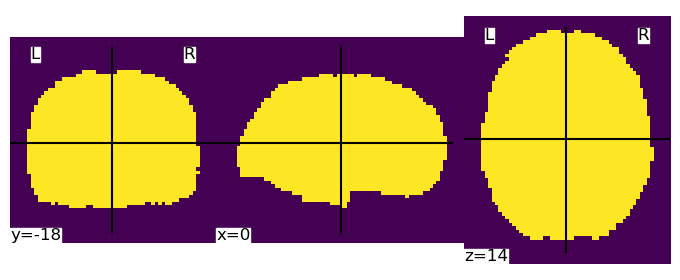

In [30]:
mask = nib.load('masks/AERONAUT_MICKEY_REST_intersect_mask.nii.gz')
plotting.plot_img(mask)

In [29]:
string = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_tphate_optt_ide.py'
all_subjects = utils.find_intersecting_subjects()
print(len(all_subjects))
with open('joblists/RM_tphate_optt_joblist.txt','w') as f:
    for i in range(len(all_subjects)):
        for task in ["Aeronaut",'Mickey','Rest']:
            f.write(f'{string} -d rest_movie -t {task} -i {i} -r 5 -s 0\n') 

string = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_isc.py'

with open('joblists/RM_isc_joblist.txt','w') as f:
    for i in range(len(all_subjects)):
        for task in ["Aeronaut",'Mickey','Rest']:
            f.write(f'{string} -d rest_movie -t {task} -i {i} -r 5 -s 0\n') 
         
    

11


In [167]:
import RM_utils as utils
string = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_denoise_DSE.py'
all_subjects = utils.get_intersecting_subjects()
print(len(all_subjects))
with open('joblists/RM_SE_at_t_joblist.txt','w') as f:
    for i in range(len(all_subjects)):
        for task in ["Aeronaut",'Mickey','Rest']:
            for m in ['TPHATE_SE_at_t','PHATE_SE_at_t']:
                f.write(f'{string} -d rest_movie -t {task} -i {i} -m {m} -r 5 -s 0\n')
                


11


In [4]:
import RM_utils as utils
string = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_DMSE_parameters.py'
all_subjects = utils.get_intersecting_subjects()
print(len(all_subjects))
with open('joblists/RM_DMSE_joblist.txt','w') as f:
    for i in range(len(all_subjects)):
        for task in ["Aeronaut",'Mickey','Rest']:
            for m in ['TPHATE_SE','DIFF_MAP_SE']:
                f.write(f'{string} -d rest_movie -t {task} -i {i} -m {m} -r 5 -s 0\n')
                


11


In [31]:
import camcan_utils as utils
string = 'srun --mpi=pmi2 python -u /gpfs/milgram/pi/turk-browne/users/elb77/task_dim/searchlight_DMSE_parameters.py'
all_subjects = utils.get_intersecting_subjects(35)
print(len(all_subjects))
with open('joblists/camcan_DMSE_joblist.txt','w') as f:
    for i in range(len(all_subjects)):
        for task in ["SMT",'REST','MOVIE']:
            for m in ['TPHATE_SE','DIFF_MAP_SE']:
                f.write(f'{string} -d camcan -t {task} -i {i} -m {m} -r 5 -s 35\n')
                


117
